In [229]:
from particles_mod.Icosphere import *
import hydrodynamic_int.hessian as hess
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
np.set_printoptions(precision=3)
pv.set_jupyter_backend('html')

In [ ]:
radius = 9.0
density = 2.0
Kpair = 0.5
Kdi = 0.5


icosphere = IcoSphere(radius=radius, density=density, Kpair=Kpair, Kdi=Kdi)


print("Number of particles:", icosphere.nparticles)

06/06/2025 12:25:11 - VLMP - INFO - [VLMP] Starting VLMP 
06/06/2025 12:25:11 - VLMP - DEBUG - [VLMP] Processing "system" component ({'type': 'simulationName', 'parameters': {'simulationName': 'Icosphere'}}), type "simulationName" (VLMP.py:194)
06/06/2025 12:25:11 - VLMP - WARNING - [VLMP] (system) Component name not specified, using "simulationName". 
06/06/2025 12:25:11 - VLMP - DEBUG - [VLMP] (system) Component name "simulationName". (VLMP.py:200)
06/06/2025 12:25:11 - VLMP - DEBUG - [VLMP] (system) Component parameters "{'simulationName': 'Icosphere'}" (VLMP.py:207)
06/06/2025 12:25:11 - VLMP - DEBUG - [VLMP] Processing "system" component ({'type': 'simulationName', 'parameters': {'simulationName': 'Icosphere'}}), type "simulationName" (VLMP.py:194)
06/06/2025 12:25:11 - VLMP - WARNING - [VLMP] (system) Component name not specified, using "simulationName". 
06/06/2025 12:25:11 - VLMP - DEBUG - [VLMP] (system) Component name "simulationName". (VLMP.py:200)
06/06/2025 12:25:11 - VLMP

Number of particles: 1002


In [231]:

hessian_analytical = icosphere.calculate_hessian()


Preliminary simulation structure created


[WARNING] UAMMD-structured Python wrapper is not compatible with UAMMD-structured self restarting mechanism
[MESSAGE] ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
[MESSAGE] ╻ ╻┏━┓┏┳┓┏┳┓╺┳┓
[MESSAGE] ┃ ┃┣━┫┃┃┃┃┃┃ ┃┃ Version: 2.5
[MESSAGE] ┗━┛╹ ╹╹ ╹╹ ╹╺┻┛
[MESSAGE] Compiled at: May 23 2025 13:23:39
[MESSAGE] Compiled in double precision mode
[MESSAGE] Computation started at Fri Jun  6 12:25:12 2025

[MESSAGE] [System] CUDA initialized
[MESSAGE] [System] Using device: NVIDIA GeForce RTX 3080 with id: 0
[MESSAGE] [System] Compute capability of the device: 8.6
[MESSAGE] ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ 
[MESSAGE] [ExtendedSystem] (system) Name: Icosphere
[MESSAGE] [ExtendedSystem] (system) Seed: 1749205512215923791
[MESSAGE] [GlobalDataBase] Fundamental not specified, using default fundamental, "Time"
[WARNING] [Time] No timeStep specified, using 0.0 as default.
[MESSAGE] [Basic] Loaded type A, mass: 1.000000, radius: 0.500000, charge: 0.000000
[MES

Read Hessian file /tmp/tmp57zut3oa/hessian.txt with shape (1004004, 11)


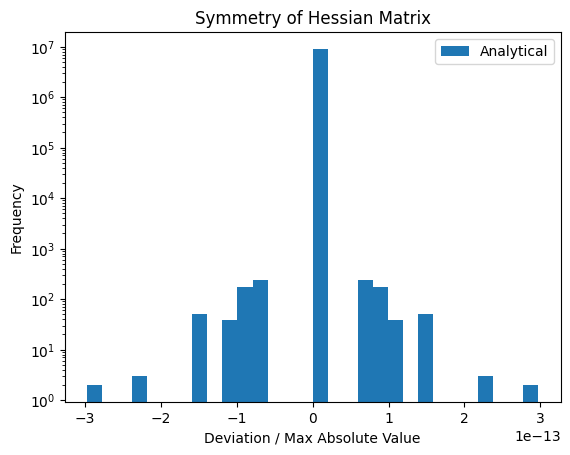

Symmetry of Hessian matrix: True


In [232]:
#symmetry = hessian - hessian.transpose(1,0,3,2)
symmetry_an = hessian_analytical - hessian_analytical.T
#symmetry = symmetry/np.mean(np.abs(hessian))
symmetry_an = symmetry_an/np.mean(np.abs(hessian_analytical))
#plt.hist(symmetry.flatten(), bins=100, alpha=0.25, label='Numerical')
plt.hist(symmetry_an.flatten(), alpha=1, label='Analytical', bins=30)
plt.title('Symmetry of Hessian Matrix')
plt.xlabel('Deviation / Max Absolute Value')
plt.ylabel('Frequency')
plt.yscale('log')
plt.legend()
plt.show()
symmetry_err = np.allclose(symmetry_an, 0.0, atol=1e-6)
print("Symmetry of Hessian matrix:", symmetry_err)

In [233]:

nparticles = icosphere.nparticles

eigenvalues, eigenvectors = hess.diagonalize_hessian(hessian_analytical)





In [234]:


print("Number of eigenvalues: ", len(eigenvalues))
print("Eigenvectors shape: ", eigenvectors.shape)

print("Maximum eigenvalue: ", np.max(eigenvalues))
print("Minimum eigenvalue: ", np.min(eigenvalues))

orthogonality = eigenvectors @ eigenvectors.T - np.eye(eigenvectors.shape[0])

print("Orthogonality error (Analytical): ", np.max(np.abs(orthogonality)))


Number of eigenvalues:  3006
Eigenvectors shape:  (3006, 3006)
Maximum eigenvalue:  47.27273305381321
Minimum eigenvalue:  -1.1347650454995031e-07
Orthogonality error (Analytical):  1.1102230246251565e-15


Number of unique eigenvalues:  394


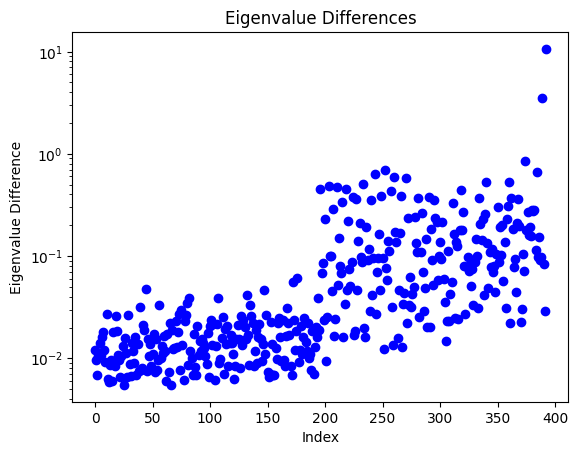

In [235]:
absolute_tolerance = 5e-3
relative_tolerance = 5e-4

# use the tolerance to determine unique eigenvalues
unique_eigenvalues = [ev for i, ev in enumerate(eigenvalues) if i == 0 or np.abs(ev - eigenvalues[i-1]) > absolute_tolerance + relative_tolerance * np.abs(ev) ]

# group the mode_groups by their eigenvalues
mode_groups = []
for i, ev in enumerate(unique_eigenvalues):
    mode_groups.append(np.where(np.isclose(eigenvalues, ev, atol=absolute_tolerance, rtol=relative_tolerance))[0])

print("Number of unique eigenvalues: ", len(unique_eigenvalues)) 

plt.scatter(range(len(unique_eigenvalues)-1), np.array(unique_eigenvalues[1:]) - np.array(unique_eigenvalues[:-1]), marker='o', color='blue', label='Eigenvalue Differences')
plt.title('Eigenvalue Differences')
plt.xlabel('Index')
plt.ylabel('Eigenvalue Difference')
plt.yscale('log')
plt.show()



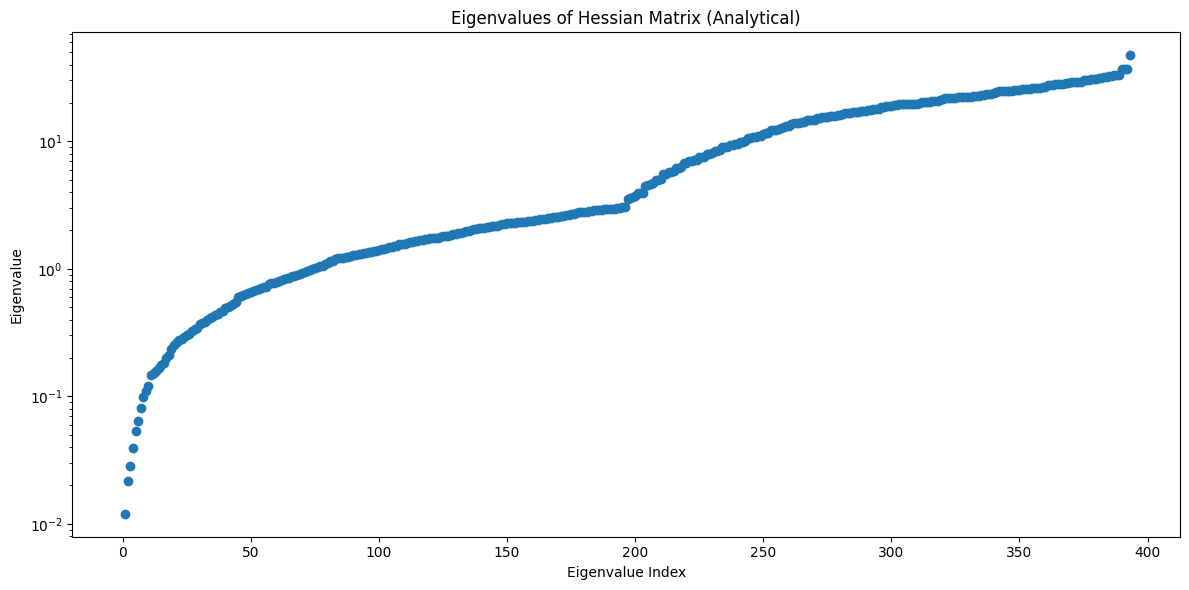

In [236]:
def plot_eigenvalues(ax, eigenvalues: np.ndarray, title : str =None):
    """
    Plot the eigenvalues of the Hessian matrix.
    :param eigenvalues: A numpy array containing the eigenvalues of the Hessian matrix.
    :param title: The title of the graph.
    """
    ax.plot(eigenvalues, 'o')
    ax.set_xlabel('Eigenvalue Index')
    ax.set_ylabel('Eigenvalue')
    ax.set_title('Eigenvalues of Hessian Matrix')
    ax.set_yscale('log')
    if title:
        plt.title(title)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
plot_eigenvalues(ax, unique_eigenvalues, title='Eigenvalues of Hessian Matrix (Analytical)')
plt.tight_layout()
plt.show()

In [240]:
def plot_mode(positions : list, eigenmode: np.ndarray):
    """
    Plot the eigenmode of the Hessian matrix.
    :param positions: A list of tuples containing the x, y and z coordinates of each particle.
    :param eigenvectors: A numpy array containing the eigenmode data in (nparticles, 3) format.
    :param mode: The index of the eigenmode to plot.
    """

    new_positions = np.array(positions) + np.array(eigenmode)   # Scale the eigenmode for visualization

    mesh = pv.PolyData(new_positions)
    mesh = mesh.delaunay_3d()
    mesh['Eigenvector'] = eigenmode  # Add the eigenmode as a scalar field for coloring
    p = pv.Plotter()
    p.add_mesh(mesh, scalars='Eigenvector', show_scalar_bar=True, show_edges=False, cmap='coolwarm')
    p.add_arrows(np.array(positions), eigenmode / np.max(np.linalg.norm(eigenmode, axis=1))*2, color='blue', opacity=0.95
                 , name='Eigenvector Arrows')
    p.window_size = [300, 250]
    # add the coordinate triad bigger
    p.add_axes(interactive=True, line_width=5, labels_off=False, color='black')
    p.show()

modes = mode_groups[0]  

for mode in modes:
    plot_mode(icosphere.positions, eigenvectors[:,mode].reshape(nparticles, 3))
    print(f"Eigenvalue {mode}: ", eigenvalues[mode])


2025-06-06 12:27:13.629 (2770.664s) [    7FBF3AF4D5C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5570580f7d10): Unable to eglMakeCurrent: 12291
2025-06-06 12:27:13.809 (2770.844s) [    7FBF3AF4D5C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x557061ae3860): Unable to eglMakeCurrent: 12291


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

Eigenvalue 0:  -1.1347650454995031e-07


2025-06-06 12:27:13.906 (2770.942s) [    7FBF3AF4D5C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5570632aa710): Unable to eglMakeCurrent: 12291
2025-06-06 12:27:14.090 (2771.125s) [    7FBF3AF4D5C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5570580f7d10): Unable to eglMakeCurrent: 12291


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

...

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

Eigenvalue 9:  0.004824342661049818


2025-06-06 12:27:16.398 (2773.434s) [    7FBF3AF4D5C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x55706b507f40): Unable to eglMakeCurrent: 12291
2025-06-06 12:27:16.567 (2773.602s) [    7FBF3AF4D5C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x55706a6dcaf0): Unable to eglMakeCurrent: 12291


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

Eigenvalue 10:  0.004824342661051491
